# NLP Project - Women Clothing Reviews Data :

## Importing Necessary Libraries and Packages :

In [2]:
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.decomposition import NMF

from xgboost import XGBClassifier

## 1. Loading Data :

In [3]:
FILE_PATH = r"Womens_Clothing_Reviews_Data.xlsx"
SHEET_NAME = "Woman Clothing Reviews"

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

## 2. Data Exploration :

In [4]:
print("Shape:", df.shape)

Shape: (23486, 11)


In [5]:
print("\nColumns:\n", df.columns.tolist())


Columns:
 ['Product ID', 'Category', 'Subcategory1', 'SubCategory2', 'Location', 'Channel', 'Customer Age', 'Review Title', 'Review Text', 'Rating', 'Recommend Flag']


In [6]:
print("\nFirst 5 rows:\n", df.head())


First 5 rows:
   Product ID        Category Subcategory1 SubCategory2   Location Channel  \
0         767       Initmates     Intimate    Intimates     Mumbai  Mobile   
1        1080         General      Dresses      Dresses  Bangalore  Mobile   
2        1077         General      Dresses      Dresses    Gurgaon  Mobile   
3        1049  General Petite      Bottoms        Pants    Chennai     Web   
4         847         General         Tops      Blouses  Bangalore     Web   

   Customer Age             Review Title  \
0            33                      NaN   
1            34                      NaN   
2            60  Some major design flaws   
3            50         My favorite buy!   
4            47         Flattering shirt   

                                         Review Text  Rating  Recommend Flag  
0  Absolutely wonderful - silky and sexy and comf...       4               1  
1  Love this dress!  it's sooo pretty.  i happene...       5               1  
2  I had such 

In [7]:
print("\nData types:\n", df.dtypes)


Data types:
 Product ID         int64
Category          object
Subcategory1      object
SubCategory2      object
Location          object
Channel           object
Customer Age       int64
Review Title      object
Review Text       object
Rating             int64
Recommend Flag     int64
dtype: object


In [8]:
print("\nMissing values:\n", df.isna().sum())


Missing values:
 Product ID           0
Category            14
Subcategory1        14
SubCategory2        14
Location             0
Channel              0
Customer Age         0
Review Title      3810
Review Text        845
Rating               0
Recommend Flag       0
dtype: int64


In [9]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 3


In [10]:
print("\nNumerical summary:\n", df.describe(include='all').T)


Numerical summary:
                   count unique  \
Product ID      23486.0    NaN   
Category          23472      3   
Subcategory1      23472      6   
SubCategory2      23472     20   
Location          23486      4   
Channel           23486      2   
Customer Age    23486.0    NaN   
Review Title      19676  13993   
Review Text       22641  22634   
Rating          23486.0    NaN   
Recommend Flag  23486.0    NaN   

                                                              top   freq  \
Product ID                                                    NaN    NaN   
Category                                                  General  13850   
Subcategory1                                                 Tops  10468   
SubCategory2                                              Dresses   6319   
Location                                                  Gurgaon   8821   
Channel                                                       Web  13583   
Customer Age                          

## 3. Basic Data Cleaning :

In [11]:
# Remove exact duplicate rows.
df = df.drop_duplicates().copy()

In [12]:
# Fill categorical missing values.
for col in ['Category', 'Subcategory1', 'SubCategory2']:
    df[col] = df[col].fillna('Unknown')

In [13]:
# Keep missing text rows instead of dropping them.
df['Review Title'] = df['Review Title'].fillna('')
df['Review Text'] = df['Review Text'].fillna('')

In [14]:
# Combine title + review text.
df['Combined Review'] = (
    df['Review Title'].astype(str).str.strip() + ' ' +
    df['Review Text'].astype(str).str.strip()
).str.strip()

In [15]:
# Remove observations with no usable review text at all only for NLP analysis.
df['Has Review Text'] = df['Combined Review'].str.len().gt(0).astype(int)

In [16]:
# Age groups for business analysis.
df['Age Group'] = pd.cut(
    df['Customer Age'],
    bins=[17, 25, 35, 45, 55, 65, np.inf],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

In [17]:
print("\nCleaned shape:", df.shape)


Cleaned shape: (23483, 14)


## 4. Cleaned Data Analysis :

In [18]:
print("\nRecommend Flag distribution:\n", df['Recommend Flag'].value_counts())


Recommend Flag distribution:
 Recommend Flag
1    19311
0     4172
Name: count, dtype: int64


In [19]:
print("\nRecommend Flag percentage:\n", df['Recommend Flag'].value_counts(normalize=True).mul(100).round(2))


Recommend Flag percentage:
 Recommend Flag
1    82.23
0    17.77
Name: proportion, dtype: float64


In [20]:
print("\nRating distribution:\n", df['Rating'].value_counts().sort_index())


Rating distribution:
 Rating
1      842
2     1565
3     2871
4     5077
5    13128
Name: count, dtype: int64


In [21]:
print("\nChannel distribution:\n", df['Channel'].value_counts())


Channel distribution:
 Channel
Web       13580
Mobile     9903
Name: count, dtype: int64


In [22]:
print("\nLocation distribution:\n", df['Location'].value_counts())


Location distribution:
 Location
Gurgaon      8818
Mumbai       7112
Bangalore    5224
Chennai      2329
Name: count, dtype: int64


In [23]:
print("\nCategory distribution:\n", df['Category'].value_counts())


Category distribution:
 Category
General           13849
General Petite     8118
Initmates          1502
Unknown              14
Name: count, dtype: int64


In [24]:
print("\nUnique products:", df['Product ID'].nunique())


Unique products: 1206


## 5. Exploratory Data Analysis :

In [25]:
def bar_plot(series, title, xlabel, ylabel='Count', rotation=0):
    ax = series.plot(kind='bar', figsize=(8, 5))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

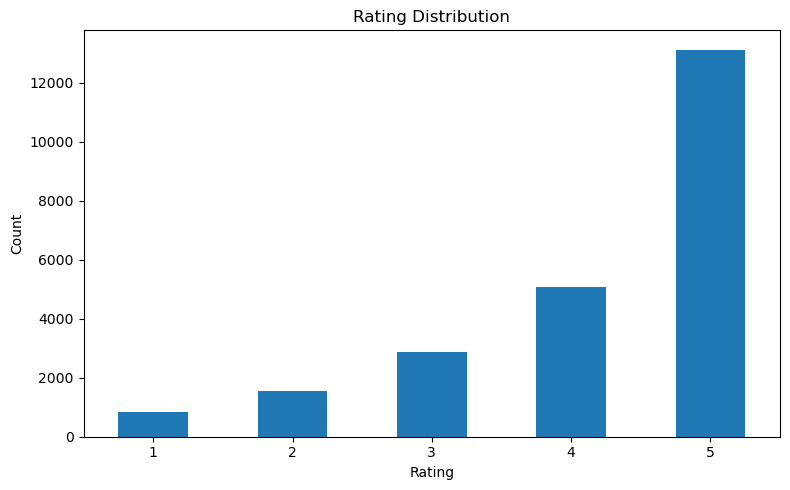

In [26]:
bar_plot(df['Rating'].value_counts().sort_index(), 'Rating Distribution', 'Rating')

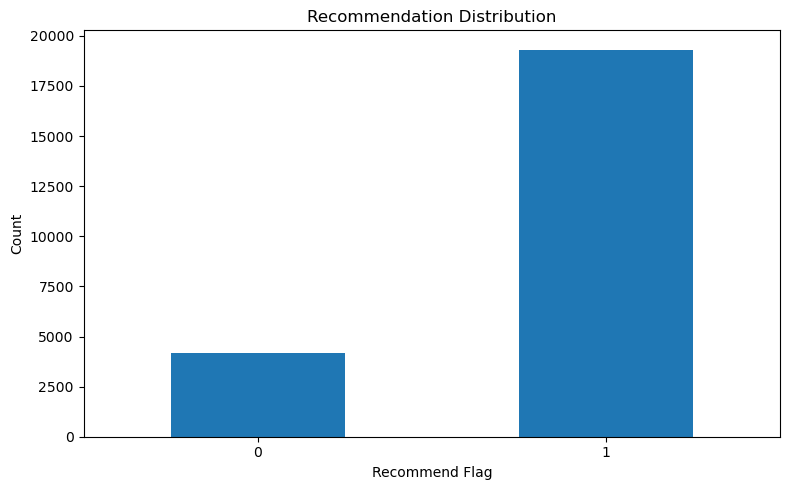

In [27]:
bar_plot(df['Recommend Flag'].value_counts().sort_index(), 'Recommendation Distribution', 'Recommend Flag')

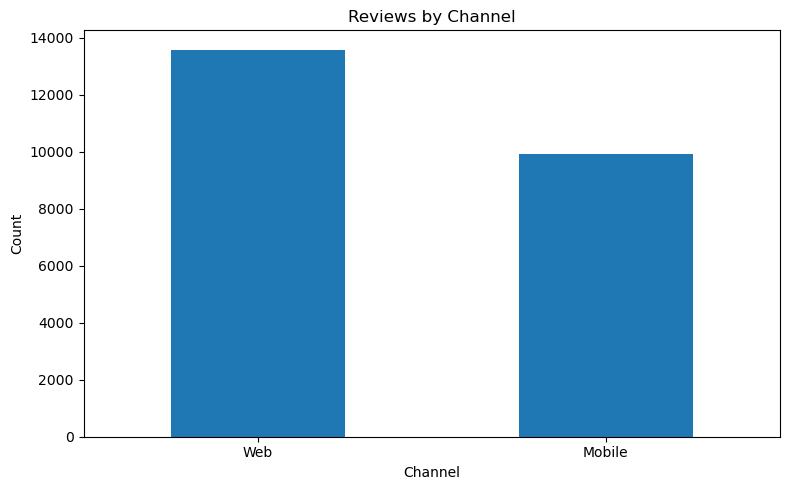

In [28]:
bar_plot(df['Channel'].value_counts(), 'Reviews by Channel', 'Channel')

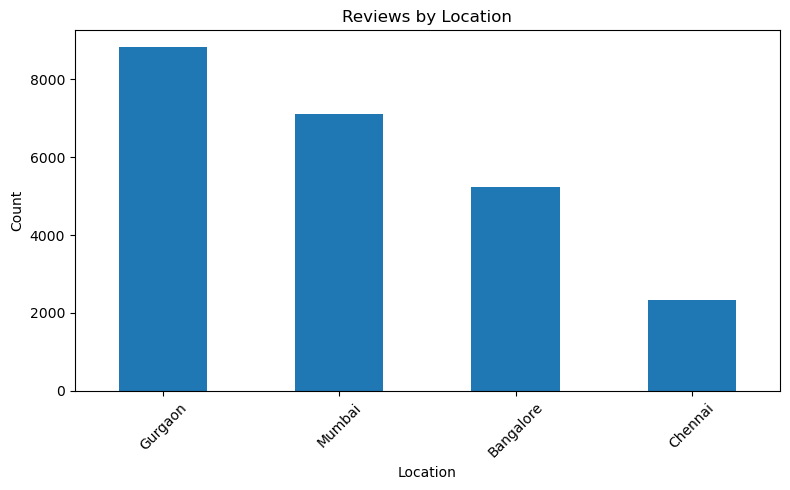

In [29]:
bar_plot(df['Location'].value_counts(), 'Reviews by Location', 'Location', rotation=45)

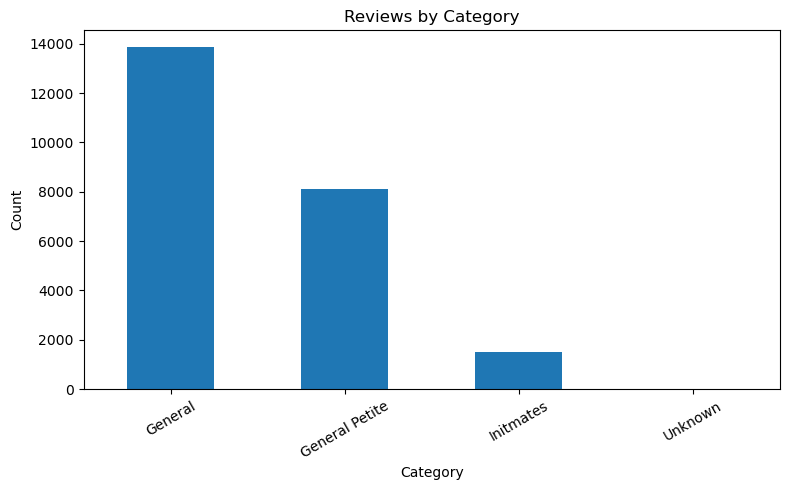

In [30]:
bar_plot(df['Category'].value_counts(), 'Reviews by Category', 'Category', rotation=30)

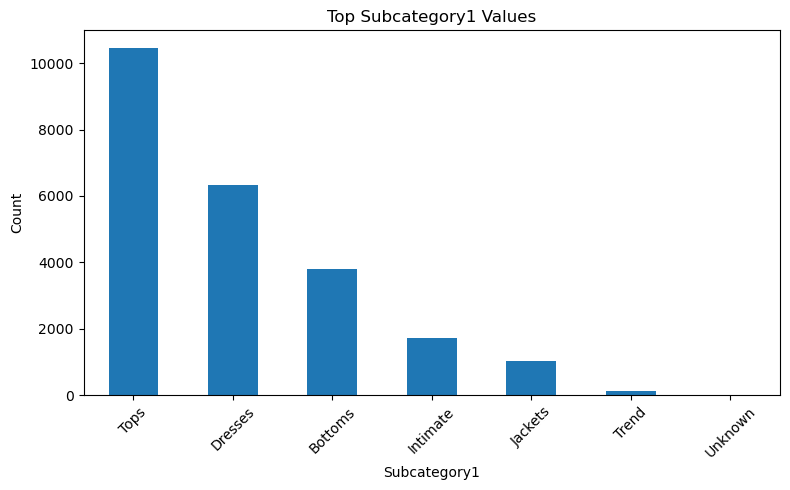

In [31]:
bar_plot(df['Subcategory1'].value_counts().head(15), 'Top Subcategory1 Values', 'Subcategory1', rotation=45)

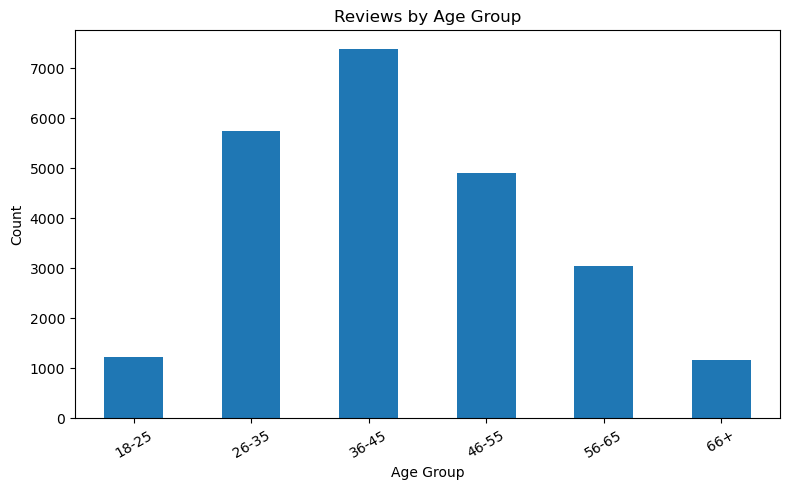

In [32]:
bar_plot(df['Age Group'].value_counts().sort_index(), 'Reviews by Age Group', 'Age Group', rotation=30)

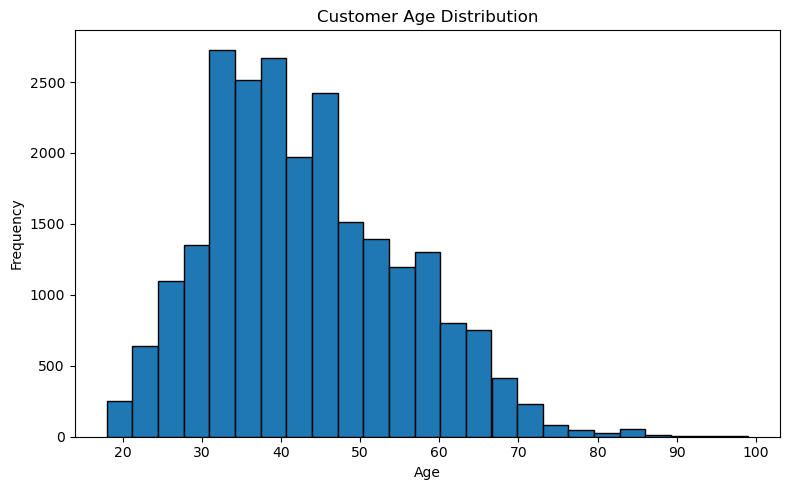

In [33]:
# Customer age distribution.
plt.figure(figsize=(8, 5))
plt.hist(df['Customer Age'], bins=25, edgecolor='black')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


Recommendation rate by Category:
 Category
Unknown           1.000
Initmates         0.852
General Petite    0.826
General           0.817
Name: Recommend Flag, dtype: float64


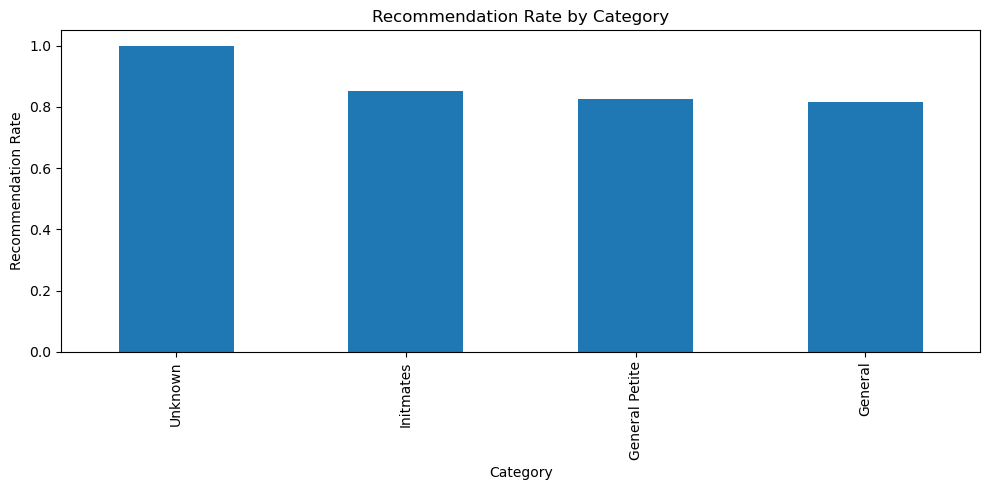


Recommendation rate by Subcategory1:
 Subcategory1
Unknown     1.000
Bottoms     0.851
Intimate    0.850
Jackets     0.836
Tops        0.815
Dresses     0.808
Trend       0.739
Name: Recommend Flag, dtype: float64


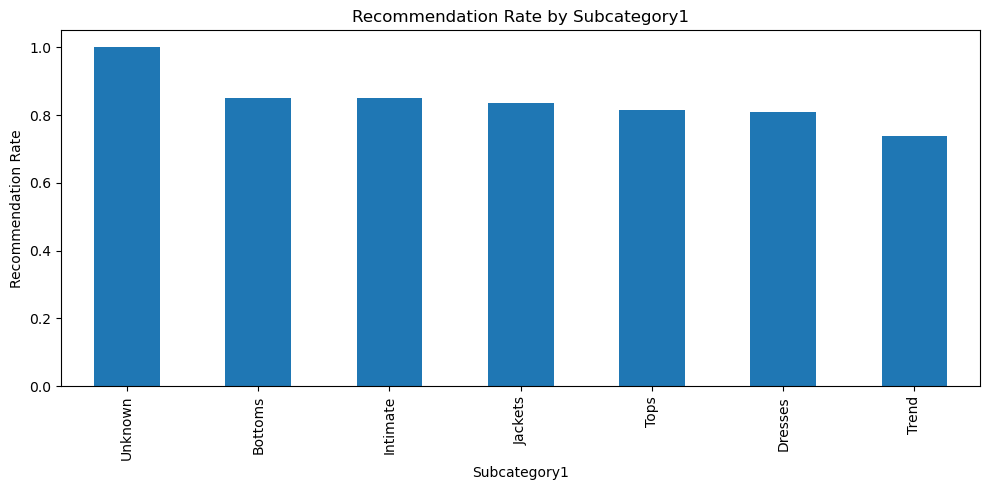


Recommendation rate by SubCategory2:
 SubCategory2
Casual bottoms    1.000
Chemises          1.000
Unknown           1.000
Layering          0.884
Jeans             0.881
Legwear           0.861
Lounge            0.860
Intimates         0.857
Sleep             0.855
Skirts            0.846
Jackets           0.845
Shorts            0.839
Fine gauge        0.837
Pants             0.833
Knits             0.818
Outerwear         0.817
Blouses           0.810
Dresses           0.808
Swim              0.806
Sweaters          0.800
Trend             0.739
Name: Recommend Flag, dtype: float64


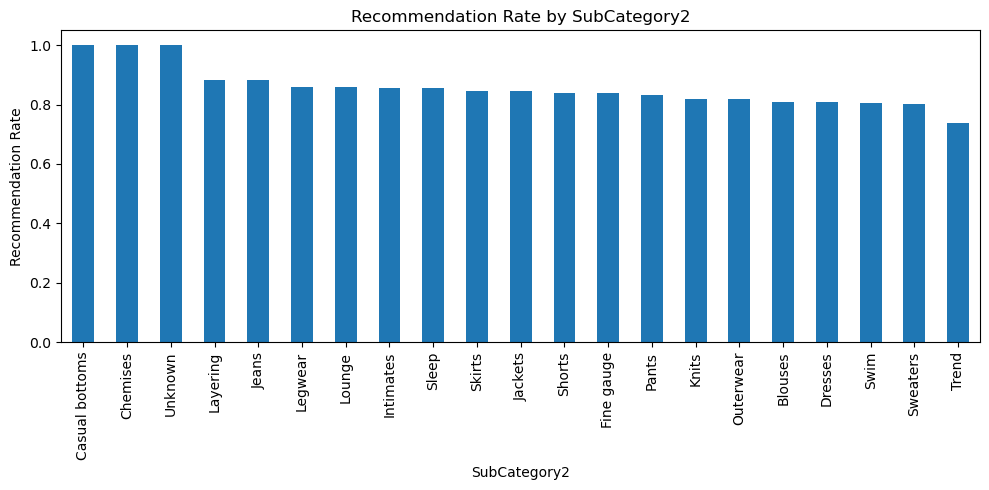


Recommendation rate by Location:
 Location
Chennai      0.826
Mumbai       0.823
Bangalore    0.822
Gurgaon      0.821
Name: Recommend Flag, dtype: float64


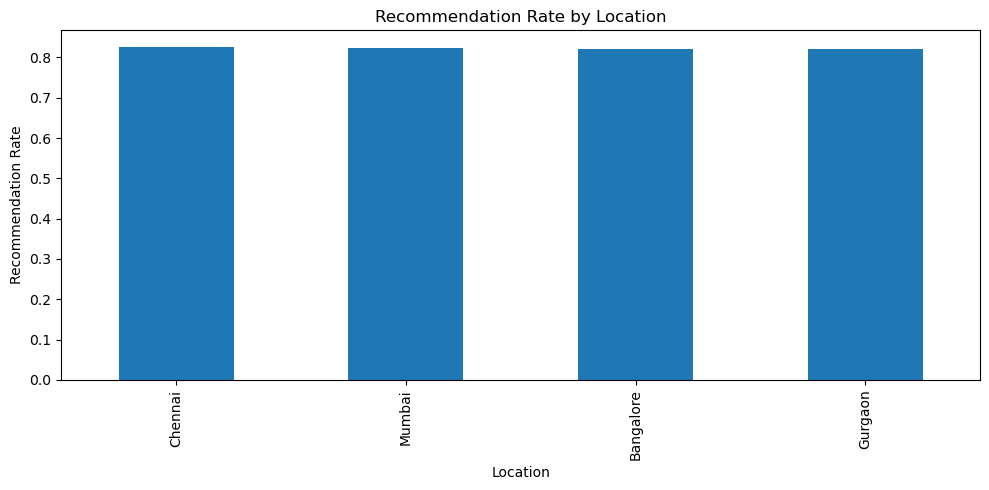


Recommendation rate by Channel:
 Channel
Mobile    0.826
Web       0.820
Name: Recommend Flag, dtype: float64


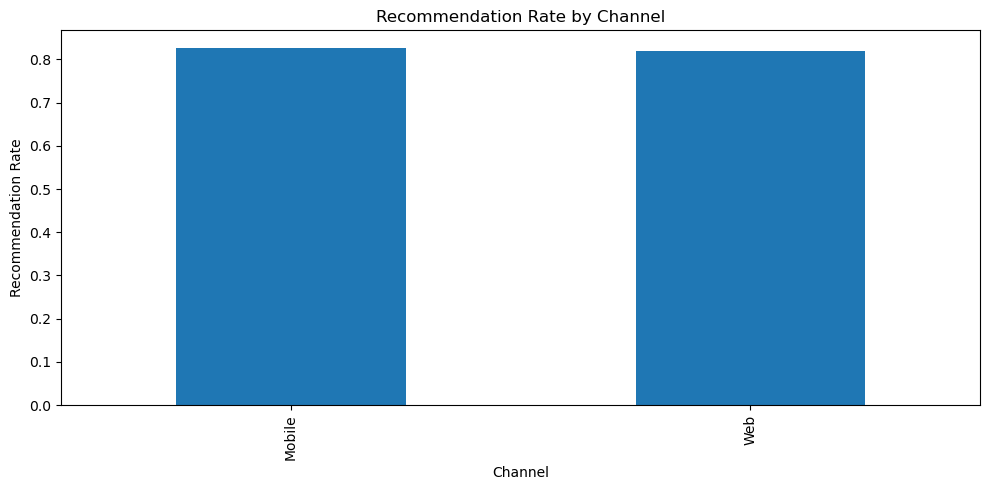


Recommendation rate by Age Group:
 Age Group
56-65    0.851
18-25    0.851
66+      0.846
46-55    0.822
36-45    0.821
26-35    0.799
Name: Recommend Flag, dtype: float64


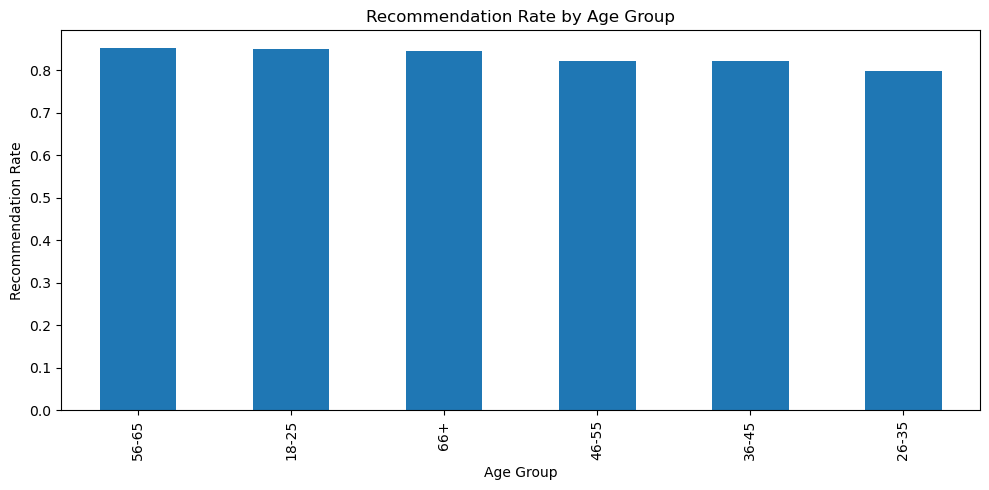

In [34]:
# Recommendation rate by selected dimensions.
for col in ['Category', 'Subcategory1', 'SubCategory2', 'Location', 'Channel', 'Age Group']:
    rate = df.groupby(col, observed=False)['Recommend Flag'].mean().sort_values(ascending=False)
    print(f"\nRecommendation rate by {col}:\n", rate.round(3))
    rate.plot(kind='bar', figsize=(10, 5), title=f'Recommendation Rate by {col}')
    plt.ylabel('Recommendation Rate')
    plt.tight_layout()
    plt.show()

In [35]:
# Average rating by selected dimensions.
for col in ['Category', 'Subcategory1', 'SubCategory2', 'Location', 'Channel', 'Age Group']:
    avg = df.groupby(col, observed=False)['Rating'].mean().sort_values(ascending=False)
    print(f"\nAverage rating by {col}:\n", avg.round(2))


Average rating by Category:
 Category
Unknown           5.00
Initmates         4.29
General Petite    4.21
General           4.18
Name: Rating, dtype: float64

Average rating by Subcategory1:
 Subcategory1
Unknown     5.00
Bottoms     4.29
Intimate    4.28
Jackets     4.26
Tops        4.17
Dresses     4.15
Trend       3.82
Name: Rating, dtype: float64

Average rating by SubCategory2:
 SubCategory2
Unknown           5.00
Casual bottoms    4.50
Layering          4.38
Jeans             4.36
Lounge            4.30
Jackets           4.30
Sleep             4.29
Intimates         4.28
Legwear           4.28
Pants             4.27
Fine gauge        4.26
Shorts            4.26
Skirts            4.25
Outerwear         4.20
Swim              4.20
Sweaters          4.18
Knits             4.16
Blouses           4.15
Dresses           4.15
Chemises          4.00
Trend             3.82
Name: Rating, dtype: float64

Average rating by Location:
 Location
Mumbai       4.21
Chennai      4.20
Gurgaon    

In [36]:
# Product-level summary: only products with at least 10 reviews.
product_summary = df.groupby('Product ID').agg(
    Reviews=('Product ID', 'size'),
    Avg_Rating=('Rating', 'mean'),
    Recommendation_Rate=('Recommend Flag', 'mean')
).query('Reviews >= 10').sort_values(['Recommendation_Rate', 'Reviews'], ascending=[False, False])

print("\nTop products by recommendation rate (min 10 reviews):\n", product_summary.head(20))


Top products by recommendation rate (min 10 reviews):
             Reviews  Avg_Rating  Recommendation_Rate
Product ID                                          
1123             30    4.700000             1.000000
1026             21    4.809524             1.000000
260              15    4.800000             1.000000
674              15    4.733333             1.000000
252              12    4.750000             1.000000
278              12    4.666667             1.000000
417              12    4.666667             1.000000
1151             11    4.636364             1.000000
479              10    4.200000             1.000000
901              10    4.700000             1.000000
1024             35    4.657143             0.971429
520              30    4.400000             0.966667
960              26    4.653846             0.961538
839              48    4.562500             0.958333
967              23    4.565217             0.956522
375              19    4.789474            

## 6. Text Cleaning :

In [37]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [38]:
df['Clean Review'] = df['Combined Review'].apply(clean_text)

In [39]:
# ------------------------------
# SENTIMENT ANALYSIS WITH VADER
# ------------------------------

In [40]:
# VADER is useful for exploratory sentiment. It is not used as the target label.
try:
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer
    try:
        sia = SentimentIntensityAnalyzer()
    except LookupError:
        nltk.download('vader_lexicon')
        sia = SentimentIntensityAnalyzer()

    df['Sentiment Score'] = df['Combined Review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    df['Sentiment'] = np.select(
        [df['Sentiment Score'] >= 0.05, df['Sentiment Score'] <= -0.05],
        ['Positive', 'Negative'],
        default='Neutral'
    )

    print("\nSentiment distribution:\n", df['Sentiment'].value_counts())
    print("\nSentiment percentages:\n", df['Sentiment'].value_counts(normalize=True).mul(100).round(2))

    for col in ['Channel', 'Location', 'Category', 'Subcategory1', 'Age Group']:
        sentiment_table = pd.crosstab(df[col], df['Sentiment'], normalize='index').mul(100).round(2)
        print(f"\nSentiment % by {col}:\n", sentiment_table)
except Exception as e:
    print("VADER sentiment section skipped:", e)


Sentiment distribution:
 Sentiment
Positive    21165
Negative     1289
Neutral      1029
Name: count, dtype: int64

Sentiment percentages:
 Sentiment
Positive    90.13
Negative     5.49
Neutral      4.38
Name: proportion, dtype: float64

Sentiment % by Channel:
 Sentiment  Negative  Neutral  Positive
Channel                               
Mobile         5.34     4.36     90.30
Web            5.60     4.40     90.01

Sentiment % by Location:
 Sentiment  Negative  Neutral  Positive
Location                              
Bangalore      5.53     4.19     90.28
Chennai        5.45     4.64     89.91
Gurgaon        5.72     4.51     89.77
Mumbai         5.19     4.27     90.54

Sentiment % by Category:
 Sentiment       Negative  Neutral  Positive
Category                                   
General             5.65     4.30     90.05
General Petite      5.25     4.19     90.56
Initmates           5.33     6.19     88.48
Unknown             0.00     7.14     92.86

Sentiment % by Subcategory1

## 7. Frequent Words and Word Clouds :

In [41]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [42]:
positive_text = ' '.join(df.loc[df['Recommend Flag'] == 1, 'Clean Review'])
negative_text = ' '.join(df.loc[df['Recommend Flag'] == 0, 'Clean Review'])

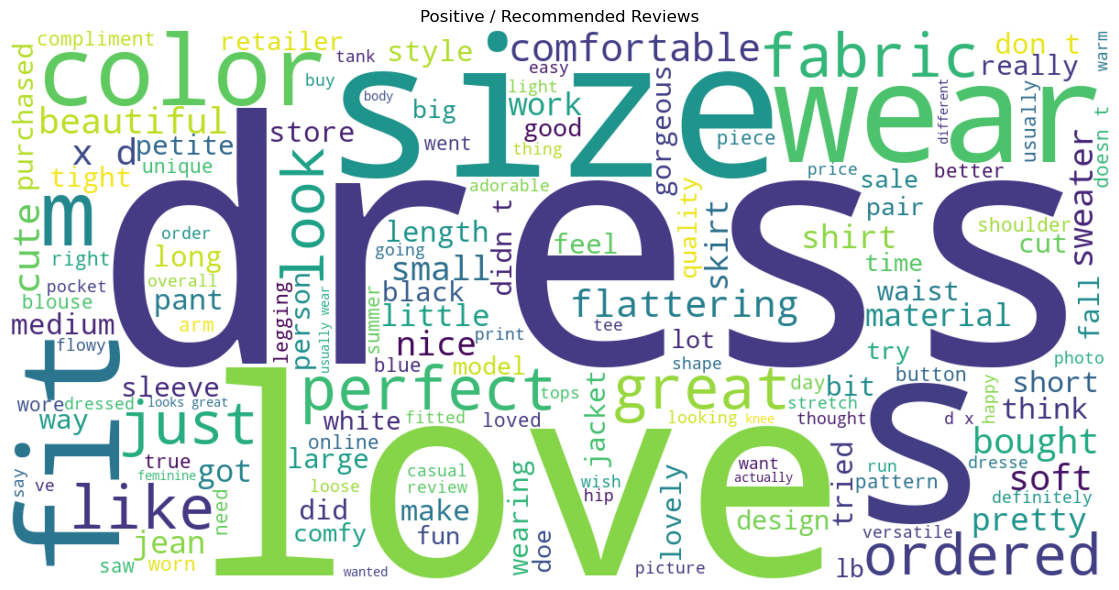

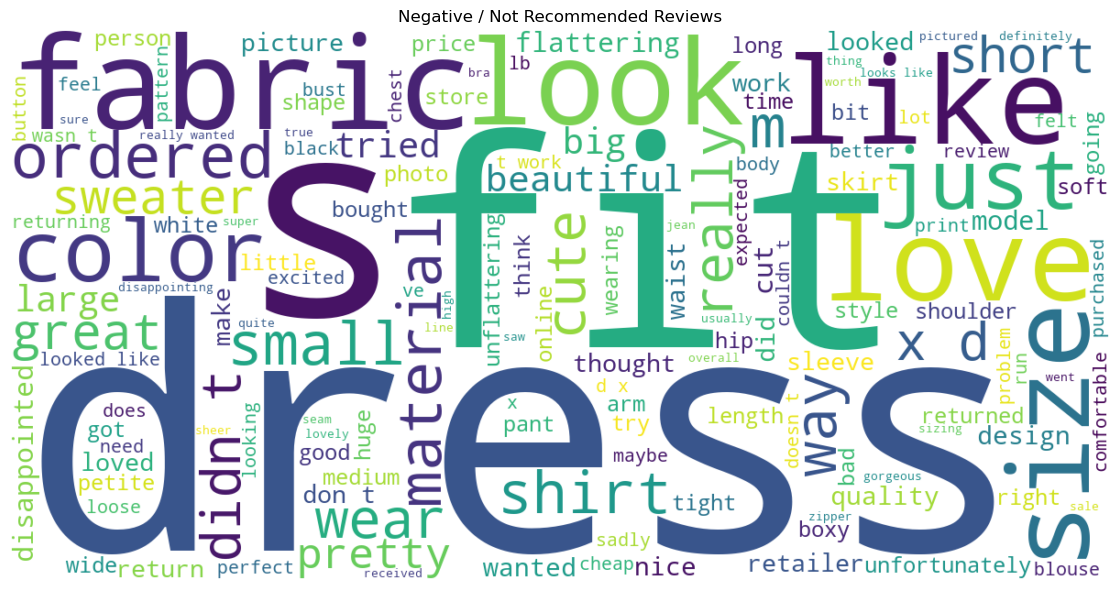

In [43]:
for text, title in [(positive_text, 'Positive / Recommended Reviews'),
                    (negative_text, 'Negative / Not Recommended Reviews')]:
    if text.strip():
        wc = WordCloud(
            width=1200,
            height=600,
            background_color='white',
            stopwords=set(ENGLISH_STOP_WORDS),
            max_words=150
        ).generate(text)
        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(title)
        plt.tight_layout()
        plt.show()

In [44]:
# Frequent unigram / bigram extraction.
def top_terms(texts, ngram_range=(1, 1), top_n=20):
    vec = CountVectorizer(stop_words='english', ngram_range=ngram_range, min_df=2)
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    idx = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({'Term': terms[idx], 'Count': counts[idx]})

In [45]:
positive_reviews = df.loc[(df['Recommend Flag'] == 1) & (df['Clean Review'] != ''), 'Clean Review']
negative_reviews = df.loc[(df['Recommend Flag'] == 0) & (df['Clean Review'] != ''), 'Clean Review']

In [46]:
print("\nTop positive unigrams:\n", top_terms(positive_reviews, (1, 1), 25))


Top positive unigrams:
            Term  Count
0         dress  10119
1          love   9750
2          size   7748
3         great   7251
4           fit   6405
5          wear   5783
6          like   5509
7          just   4524
8       perfect   4371
9         color   4137
10        small   4056
11         cute   3855
12    beautiful   3760
13       fabric   3712
14       little   3557
15   flattering   3523
16         soft   3473
17  comfortable   3353
18       really   3160
19         look   3149
20         nice   3084
21      ordered   3034
22         fits   2738
23       bought   2714
24          bit   2620


In [47]:
print("\nTop negative unigrams:\n", top_terms(negative_reviews, (1, 1), 25))


Top negative unigrams:
          Term  Count
0       dress   2102
1        like   1879
2         fit   1534
3      fabric   1370
4        just   1310
5        size   1230
6        love   1069
7       small   1013
8        look    998
9      really    915
10    ordered    826
11   material    783
12      color    779
13       wear    773
14       cute    741
15      shirt    714
16        way    703
17    quality    698
18      looks    663
19      great    657
20      large    621
21  beautiful    612
22       didn    604
23     looked    601
24     wanted    579


In [48]:
print("\nTop positive bigrams:\n", top_terms(positive_reviews, (2, 2), 20))


Top positive bigrams:
                 Term  Count
0          true size   1266
1         love dress    843
2          love love    683
3       usually wear    587
4        looks great    584
5      fit perfectly    558
6     fits perfectly    489
7         super cute    477
8         size small    462
9         runs large    426
10        usual size    417
11        just right    415
12  highly recommend    369
13        super soft    351
14   beautiful dress    341
15        runs small    341
16          size fit    336
17  soft comfortable    333
18         fit great    327
19       dress dress    327


In [49]:
print("\nTop negative bigrams:\n", top_terms(negative_reviews, (2, 2), 20))


Top negative bigrams:
              Term  Count
0     wanted love    333
1     looked like    198
2      looks like    172
3   really wanted    167
4       look like    141
5       didn work    132
6      runs small    116
7       felt like    111
8       true size    106
9    poor quality    105
10     love dress    104
11   usually wear    104
12      just didn    101
13     runs large     98
14     size small     87
15    wanted like     78
16      arm holes     74
17      don think     71
18  ordered small     71
19     high hopes     69


## 8. Topic Mining With NMF :

In [50]:
# NMF - Non Negative Matrix factorization : 
# It is an unsupervised machine learning technique used to discover hidden semantic structures and main themes (topics) in a collection of text documents.

In [51]:
text_for_topics = df.loc[df['Clean Review'] != '', 'Clean Review']

In [52]:
topic_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    min_df=5,
    max_df=0.90,
    ngram_range=(1, 2)
)

In [53]:
X_topics = topic_vectorizer.fit_transform(text_for_topics)

In [54]:
N_TOPICS = 8
nmf = NMF(n_components=N_TOPICS, random_state=42, init='nndsvda', max_iter=400)

In [55]:
W = nmf.fit_transform(X_topics)

In [56]:
H = nmf.components_

In [57]:
terms = np.array(topic_vectorizer.get_feature_names_out())

In [58]:
print("\nTOPICS")

for topic_idx, weights in enumerate(H):
    top_words = terms[weights.argsort()[::-1][:12]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")


TOPICS
Topic 1: like, fabric, just, look, really, nice, pretty, fit, didn, color, skirt, good
Topic 2: dress, love dress, beautiful, beautiful dress, dress dress, perfect, flattering, summer, great dress, slip, wear, dress beautiful
Topic 3: love, love love, love dress, absolutely, color, absolutely love, colors, compliments, fits, wanted love, love color, bought
Topic 4: size, small, large, runs, medium, ordered, usually, wear, true, big, fit, xs
Topic 5: sweater, soft, love sweater, beautiful, warm, cozy, color, sleeves, coat, beautiful sweater, fall, itchy
Topic 6: cute, super, super cute, comfy, really cute, little, really, comfortable, cute comfortable, cute comfy, cute dress, super soft
Topic 7: great, jeans, pants, perfect, comfortable, fit, wear, summer, pair, soft, fall, looks great
Topic 8: shirt, love shirt, white, great shirt, shirt love, soft, tee, cute shirt, shirts, shirt great, material, shirt shirt


In [59]:
# Dominant topic back to rows used in topic model.
topic_rows = text_for_topics.index
df.loc[topic_rows, 'Dominant Topic'] = W.argmax(axis=1) + 1
print("\nDominant topic distribution:\n", df['Dominant Topic'].value_counts().sort_index())


Dominant topic distribution:
 Dominant Topic
1.0    3931
2.0    3830
3.0    2039
4.0    4134
5.0    1753
6.0    1784
7.0    3545
8.0    1626
Name: count, dtype: int64


## 9. Recommendation Classification Data Preparation :

In [60]:
# Rating is intentionally excluded by default to reduce outcome leakage.
# Product ID is treated as categorical because it identifies product differences.

In [61]:
model_df = df.copy()

In [62]:
TEXT_COL = 'Clean Review'
CAT_COLS = ['Product ID', 'Category', 'Subcategory1', 'SubCategory2', 'Location', 'Channel']
NUM_COLS = ['Customer Age', 'Has Review Text']
TARGET = 'Recommend Flag'

In [63]:
X = model_df[[TEXT_COL] + CAT_COLS + NUM_COLS]
y = model_df[TARGET].astype(int)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [65]:
# TF-IDF fitted only on training data.
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3500,
    min_df=3,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

In [66]:
Xtr_text = tfidf.fit_transform(X_train[TEXT_COL])

In [67]:
Xte_text = tfidf.transform(X_test[TEXT_COL])

In [68]:
# One-hot encode categorical columns.
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

In [69]:
Xtr_cat = ohe.fit_transform(X_train[CAT_COLS].astype(str))

In [70]:
Xte_cat = ohe.transform(X_test[CAT_COLS].astype(str))

In [71]:
# Scale numeric columns to non-negative [0, 1], compatible with MultinomialNB.
scaler = MinMaxScaler()

In [72]:
Xtr_num = csr_matrix(scaler.fit_transform(X_train[NUM_COLS]))

In [73]:
Xte_num = csr_matrix(scaler.transform(X_test[NUM_COLS]))

In [74]:
# Full sparse design matrix.
X_train_final = hstack([Xtr_text, Xtr_cat, Xtr_num], format='csr')
X_test_final = hstack([Xte_text, Xte_cat, Xte_num], format='csr')

In [75]:
feature_names = np.concatenate([
    np.array([f"TEXT__{x}" for x in tfidf.get_feature_names_out()]),
    np.array([f"CAT__{x}" for x in ohe.get_feature_names_out(CAT_COLS)]),
    np.array([f"NUM__{x}" for x in NUM_COLS])
])

In [76]:
print("\nTraining matrix:", X_train_final.shape)
print("Testing matrix:", X_test_final.shape)


Training matrix: (18786, 4653)
Testing matrix: (4697, 4653)


## 10. Evaluation Function :

In [77]:
results = []
trained_models = {}

In [78]:
def evaluate_model(name, model, Xte=X_test_final, yte=y_test):
    pred = model.predict(Xte)

    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(yte, prob)
    elif hasattr(model, 'decision_function'):
        score = model.decision_function(Xte)
        auc = roc_auc_score(yte, score)
    else:
        auc = np.nan

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(yte, pred),
        'Balanced Accuracy': balanced_accuracy_score(yte, pred),
        'Precision': precision_score(yte, pred, zero_division=0),
        'Recall': recall_score(yte, pred, zero_division=0),
        'F1': f1_score(yte, pred, zero_division=0),
        'ROC_AUC': auc
    }
    results.append(metrics)
    trained_models[name] = model

    print("\n" + '=' * 70)
    print(name)
    print('=' * 70)
    print(pd.Series(metrics))
    print("\nClassification report:\n", classification_report(yte, pred, digits=4))
    print("\nConfusion matrix:\n", confusion_matrix(yte, pred))

    ConfusionMatrixDisplay.from_predictions(yte, pred)
    plt.title(name)
    plt.tight_layout()
    plt.show()

    return metrics

In [79]:
# Common cross-validation setup.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'roc_auc'
N_JOBS = -1

## 11. Logistic Regression Algorithm using GridSearchCV :

In [80]:
lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='liblinear',
    random_state=42
)

In [81]:
lr_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'penalty': ['l1', 'l2']
}

In [82]:
lr_search = GridSearchCV(
    lr, lr_grid, cv=cv, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [83]:
lr_search.fit(X_train_final, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=2000, random_state=42,
                                          solver='liblinear'),
             n_jobs=-1,
             param_grid={'C': [0.1, 0.5, 1, 2, 5], 'penalty': ['l1', 'l2']},
             scoring='roc_auc', verbose=1)

In [ ]:
print("Best Logistic Regression params:", lr_search.best_params_)

In [ ]:
print("Best CV ROC-AUC:", lr_search.best_score_)

In [ ]:
evaluate_model('Logistic Regression', lr_search.best_estimator_)

In [ ]:
# OPTIONAL RFE FOR LOGISTIC REGRESSION
# RFE on thousands of sparse TF-IDF features is computationally expensive.
# Run this only if explicitly needed and enough RAM/time is available.
RUN_RFE_LOGISTIC = False
if RUN_RFE_LOGISTIC:
    rfe_lr_estimator = LogisticRegression(
        C=lr_search.best_params_['C'],
        penalty='l2',
        solver='liblinear',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    rfe_lr = RFE(
        estimator=rfe_lr_estimator,
        n_features_to_select=min(800, X_train_final.shape[1]),
        step=0.20,
        verbose=1
    )
    Xtr_lr_rfe = rfe_lr.fit_transform(X_train_final, y_train)
    Xte_lr_rfe = rfe_lr.transform(X_test_final)
    lr_rfe_model = rfe_lr_estimator.fit(Xtr_lr_rfe, y_train)
    evaluate_model('Logistic Regression + RFE', lr_rfe_model, Xte_lr_rfe, y_test)



## 12. KNN Classifier Algorithm using GridSearchCV :

In [ ]:
# KNN can be slow in high-dimensional sparse NLP space.

In [ ]:
knn = KNeighborsClassifier()
knn_grid = {
    'n_neighbors': [25],
    'weights': ['uniform'],
    'metric': ['euclidean']
}
knn_search = GridSearchCV(
    knn, knn_grid, cv=3, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [ ]:
knn_search.fit(X_train_final, y_train)

In [ ]:
print("Best KNN params:", knn_search.best_params_)

In [ ]:
print("Best CV ROC-AUC:", knn_search.best_score_)

In [ ]:
evaluate_model('KNN Classifier', knn_search.best_estimator_)

In [ ]:
# RFE is not appropriate for KNN because KNN has no coefficients or feature_importances_.

## 13. Multinomial Naive Bayes Algorithm using GridSearchCV :

In [ ]:
# MultinomialNB is more suitable than GaussianNB for non-negative sparse NLP features.

In [ ]:
nb = MultinomialNB()
nb_grid = {
    'alpha': [0.05, 0.1, 0.25, 0.5, 1.0, 2.0],
    'fit_prior': [True, False]
}
nb_search = GridSearchCV(
    nb, nb_grid, cv=cv, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [ ]:
nb_search.fit(X_train_final, y_train)

In [ ]:
print("Best Naive Bayes params:", nb_search.best_params_)

In [ ]:
print("Best CV ROC-AUC:", nb_search.best_score_)

In [ ]:
evaluate_model('Multinomial Naive Bayes', nb_search.best_estimator_)

In [ ]:
# RFE is usually not used with MultinomialNB in this sparse NLP setting.

## 14. Decision Tree Algorithm using GridSearchCV :

In [ ]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_grid = {
    'criterion': ['entropy'],
    'max_depth': [20],
    'min_samples_split': [25],
    'min_samples_leaf': [10],
    'max_features': [None]
}
dt_search = GridSearchCV(
    dt, dt_grid, cv=3, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [ ]:
dt_search.fit(X_train_final, y_train)

In [ ]:
print("Best Decision Tree params:", dt_search.best_params_)

In [ ]:
print("Best CV ROC-AUC:", dt_search.best_score_)

In [ ]:
evaluate_model('Decision Tree Classifier', dt_search.best_estimator_)

In [ ]:
# OPTIONAL RFE: technically possible because a tree exposes feature_importances_,
# but generally not efficient for large sparse text matrices.
RUN_RFE_TREE = False
if RUN_RFE_TREE:
    rfe_dt = RFE(
        estimator=DecisionTreeClassifier(
            max_depth=10,
            class_weight='balanced',
            random_state=42
        ),
        n_features_to_select=min(800, X_train_final.shape[1]),
        step=0.20,
        verbose=1
    )
    Xtr_dt_rfe = rfe_dt.fit_transform(X_train_final, y_train)
    Xte_dt_rfe = rfe_dt.transform(X_test_final)
    dt_rfe_model = dt_search.best_estimator_.fit(Xtr_dt_rfe, y_train)
    evaluate_model('Decision Tree + RFE', dt_rfe_model, Xte_dt_rfe, y_test)



## 15. Bagging Classifier Algorithm using GridSearchCV :

In [ ]:
base_tree = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)

bag = BaggingClassifier(
    estimator=base_tree,
    random_state=42,
    n_jobs=N_JOBS
)

bag_grid = {
    'n_estimators': [50],
    'max_samples': [0.6],
    'max_features': [0.6],
    'bootstrap': [True]
}

bag_search = GridSearchCV(
    bag, bag_grid, cv=3, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)


In [ ]:
bag_search.fit(X_train_final, y_train)

In [ ]:
print("Best Bagging params:", bag_search.best_params_)

In [ ]:
print("Best CV ROC-AUC:", bag_search.best_score_)

In [ ]:
evaluate_model('Bagging Classifier', bag_search.best_estimator_)

In [ ]:
# Standard RFE is not directly appropriate for BaggingClassifier because the ensemble
# itself does not provide one simple coef_ / feature_importances_ vector for RFE.

## 16. Random Forest Algorithm using GridSearchCV :

In [ ]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=N_JOBS
)

rf_grid = {
    'n_estimators': [150],
    'max_depth': [None],
    'min_samples_split': [6],
    'min_samples_leaf': [1],
    'max_features': ['sqrt']
}

rf_search = GridSearchCV(
    rf, rf_grid, cv=3, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [ ]:
rf_search.fit(X_train_final, y_train)

In [ ]:
print("Best Random Forest params:", rf_search.best_params_)

In [ ]:
print("Best CV ROC-AUC:", rf_search.best_score_)

In [ ]:
evaluate_model('Random Forest Classifier', rf_search.best_estimator_)

In [ ]:
# OPTIONAL RFE FOR RANDOM FOREST - usually expensive on NLP feature matrices.
RUN_RFE_RF = False
if RUN_RFE_RF:
    rfe_rf = RFE(
        estimator=RandomForestClassifier(
            n_estimators=150,
            max_depth=15,
            class_weight='balanced',
            random_state=42,
            n_jobs=N_JOBS
        ),
        n_features_to_select=min(800, X_train_final.shape[1]),
        step=0.25,
        verbose=1
    )
    Xtr_rf_rfe = rfe_rf.fit_transform(X_train_final, y_train)
    Xte_rf_rfe = rfe_rf.transform(X_test_final)
    rf_rfe_model = rf_search.best_estimator_.fit(Xtr_rf_rfe, y_train)
    evaluate_model('Random Forest + RFE', rf_rfe_model, Xte_rf_rfe, y_test)

## 17. XGBoost Classifier Algorithm using GridSearchCV :

In [ ]:
# scale_pos_weight = negatives / positives for class 1 weighting is generally <1 here;
# however we keep evaluation stratified and tune regularization rather than force it.

In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    tree_method='hist',
    n_jobs=N_JOBS
)

xgb_grid = {
    'n_estimators': [125],
    'learning_rate': [0.03]
}

xgb_search = GridSearchCV(
    xgb, xgb_grid, cv=3, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [ ]:
xgb_search.fit(X_train_final, y_train)

In [ ]:
print("Best XGBoost params:", xgb_search.best_params_)

In [ ]:
print("Best CV ROC-AUC:", xgb_search.best_score_)

In [ ]:
evaluate_model('XGBoost Classifier', xgb_search.best_estimator_)

In [ ]:
# RFE is technically possible with XGBoost but is usually prohibitively expensive
# when nested around boosted-tree training and thousands of NLP features.

## 18. Model Comparison :

In [ ]:
results_df = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False)
print("\nFINAL MODEL COMPARISON\n", results_df.round(4))

In [ ]:
results_df.set_index('Model')[['ROC_AUC', 'F1', 'Balanced Accuracy', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(12, 6)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 19. Driver / Feature Importance Analysis :

In [ ]:
# Logistic coefficients are especially useful for interpreting positive/negative drivers.

In [ ]:
best_lr = lr_search.best_estimator_

In [ ]:
coef = best_lr.coef_.ravel()

In [ ]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
}).sort_values('Coefficient')

In [ ]:
print("\nTop drivers of NOT recommending (negative coefficients):\n", coef_df.head(30))
print("\nTop drivers of recommending (positive coefficients):\n", coef_df.tail(30).sort_values('Coefficient', ascending=False))

In [ ]:
# Random Forest feature importances.
best_rf = rf_search.best_estimator_
rf_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop Random Forest features:\n", rf_imp.head(40))

In [ ]:
# XGBoost feature importances.
best_xgb = xgb_search.best_estimator_
xgb_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop XGBoost features:\n", xgb_imp.head(40))

In [ ]:
# ==============================================================
# 20. OPTIONAL: RATING PREDICTION (MULTICLASS)
# PDF also requests predicting rating based on review.
# ==============================================================
# This section uses text + demographics/category information and predicts rating 1-5.
# It does NOT include Recommend Flag, to avoid another target-outcome leakage shortcut.

In [ ]:
RUN_RATING_MODEL = True
if RUN_RATING_MODEL:
    y_rating = df['Rating'].astype(int)
    X_rating = df[[TEXT_COL] + CAT_COLS + NUM_COLS]

    Xr_train, Xr_test, yr_train, yr_test = train_test_split(
        X_rating, y_rating,
        test_size=0.20,
        random_state=42,
        stratify=y_rating
    )

    r_tfidf = TfidfVectorizer(
        stop_words='english', max_features=3500,
        min_df=3, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True
    )
    Xrtr_text = r_tfidf.fit_transform(Xr_train[TEXT_COL])
    Xrte_text = r_tfidf.transform(Xr_test[TEXT_COL])

    r_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    Xrtr_cat = r_ohe.fit_transform(Xr_train[CAT_COLS].astype(str))
    Xrte_cat = r_ohe.transform(Xr_test[CAT_COLS].astype(str))

    r_scaler = MinMaxScaler()
    Xrtr_num = csr_matrix(r_scaler.fit_transform(Xr_train[NUM_COLS]))
    Xrte_num = csr_matrix(r_scaler.transform(Xr_test[NUM_COLS]))

    Xr_train_final = hstack([Xrtr_text, Xrtr_cat, Xrtr_num], format='csr')
    Xr_test_final = hstack([Xrte_text, Xrte_cat, Xrte_num], format='csr')

    rating_lr = LogisticRegression(
        max_iter=2500,
        class_weight='balanced',
        solver='saga',
        multi_class='auto',
        random_state=42
    )
    rating_grid = {
        'C': [0.25, 0.5, 1.0, 2.0]
    }
    rating_search = GridSearchCV(
        rating_lr,
        rating_grid,
        scoring='f1_macro',
        cv=3,
        n_jobs=N_JOBS,
        verbose=1
    )
    rating_search.fit(Xr_train_final, yr_train)
    rating_pred = rating_search.predict(Xr_test_final)

    print("\nBest rating model params:", rating_search.best_params_)
    print("\nRating prediction classification report:\n",
          classification_report(yr_test, rating_pred, digits=4))
    print("\nRating confusion matrix:\n", confusion_matrix(yr_test, rating_pred))



In [ ]:
# # ==============================================================
# # 21. SAVE IMPORTANT OUTPUTS
# # ==============================================================
# results_df.to_csv('model_comparison.csv', index=False)
# product_summary.to_csv('product_summary.csv')
# coef_df.to_csv('logistic_regression_drivers.csv', index=False)
# rf_imp.to_csv('random_forest_feature_importance.csv', index=False)
# xgb_imp.to_csv('xgboost_feature_importance.csv', index=False)

# print("\nAnalysis complete. Output CSV files have been saved.")